FamilySize
1     535
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


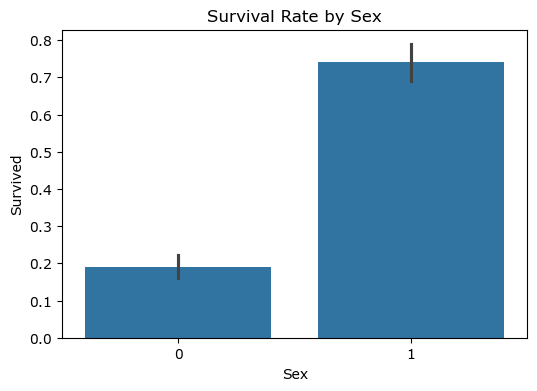

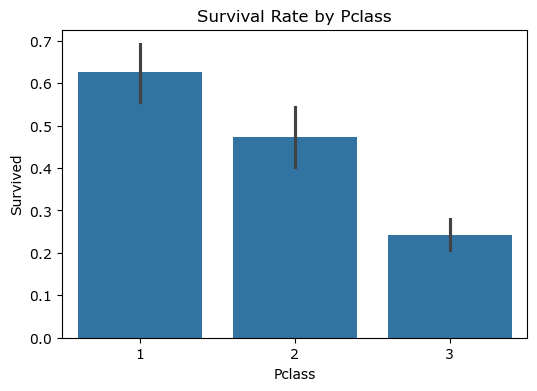

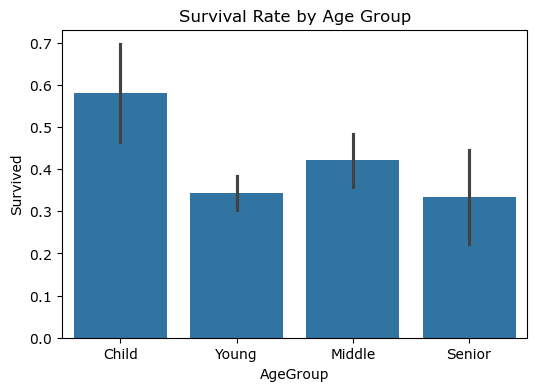

准确率 (Accuracy): 0.7697

分类报告 (Classification Report):
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       109
           1       0.69      0.72      0.71        69

    accuracy                           0.77       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.77      0.77       178



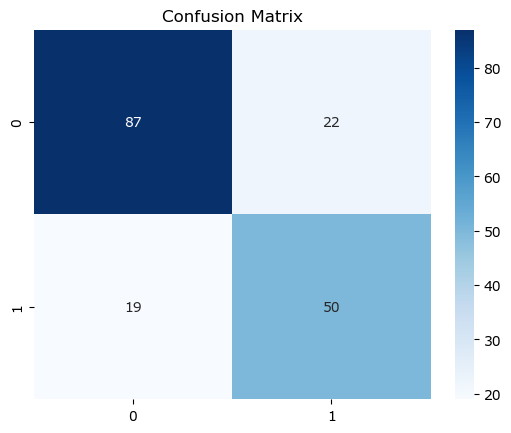

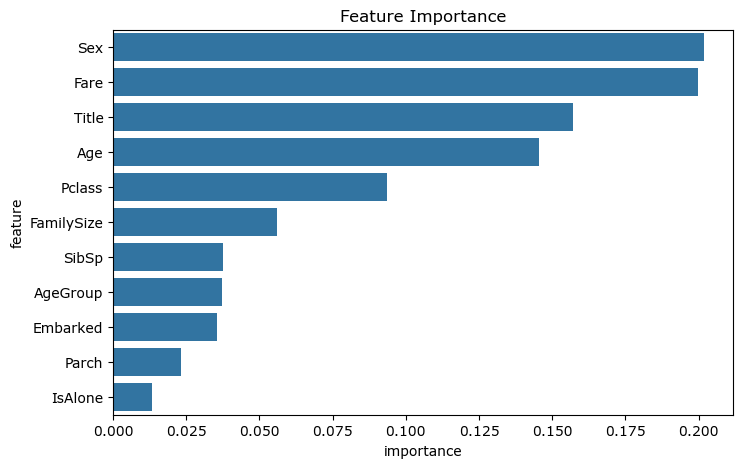

In [4]:
# ============================================================
# Titanic Survival Prediction - Full Pipeline
# ============================================================

# ===== 1. Setup and data loading =====
%matplotlib inline
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load training data
train = pd.read_csv('titanic.csv')

# ===== 2. Data cleaning =====
# Drop rows with missing Embarked (very few)
train = train.dropna(subset=['Embarked'])
# Fill missing Age with median
train['Age'] = train['Age'].fillna(train['Age'].median())
# Fill missing Cabin with 'Unknown'
train['Cabin'] = train['Cabin'].fillna('Unknown')

# ===== 3. Feature engineering =====
# Encode Sex: male -> 0, female -> 1
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
# Extract Title from Name (Mr, Mrs, Miss, etc.)
train['Title'] = train['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
# Family size = siblings/spouse + parents/children + self
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
# Whether passenger is traveling alone
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)

# Check family size distribution
print(train['FamilySize'].value_counts().sort_index())

# Age binning (based on survival patterns)
bins = [0, 12, 30, 50, 80]
labels = ['Child', 'Young', 'Middle', 'Senior']
train['AgeGroup'] = pd.cut(train['Age'], bins=bins, labels=labels)

# ===== 4. EDA: Survival rate by key features =====
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

# Figure 1: Survival by Sex
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=train)
plt.title('Survival Rate by Sex')
plt.savefig('eda_sex.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Survival by Pclass
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title('Survival Rate by Pclass')
plt.savefig('eda_pclass.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3: Survival by Age Group
plt.figure(figsize=(6,4))
sns.barplot(x='AgeGroup', y='Survived', data=train)
plt.title('Survival Rate by Age Group')
plt.savefig('eda_agegroup.png', dpi=150, bbox_inches='tight')
plt.show()

# ===== 5. Encode categorical variables =====
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Sex', 'Embarked', 'Title', 'AgeGroup']
encoder = LabelEncoder()
for col in categorical_cols:
    train[col] = encoder.fit_transform(train[col])

# ===== 6. Define features and target =====
X = train[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup']]
y = train['Survived']

# ===== 7. Train/validation split =====
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ===== 8. Train Random Forest model =====
model = RandomForestClassifier(n_estimators=100, max_depth=10,random_state=42)
model.fit(X_train, y_train)

# ===== 9. Evaluate on validation set =====
y_pred = model.predict(X_val)

print(f"准确率 (Accuracy): {accuracy_score(y_val, y_pred):.4f}")
print("\n分类报告 (Classification Report):")
print(classification_report(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=importance)
plt.title('Feature Importance')
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

